In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
df = pd.read_csv('../data/raw/beer_reviews.csv')

print(f"Shape: {df.shape}")
print(f"\nColunas:\n{df.dtypes}")
print(f"\nNulls:\n{df.isnull().sum()}")

Shape: (1586614, 13)

Colunas:
brewery_id              int64
brewery_name              str
review_time             int64
review_overall        float64
review_aroma          float64
review_appearance     float64
review_profilename        str
beer_style                str
review_palate         float64
review_taste          float64
beer_name                 str
beer_abv              float64
beer_beerid             int64
dtype: object

Nulls:
brewery_id                0
brewery_name             15
review_time               0
review_overall            0
review_aroma              0
review_appearance         0
review_profilename      348
beer_style                0
review_palate             0
review_taste              0
beer_name                 0
beer_abv              67785
beer_beerid               0
dtype: int64


In [4]:
# Dropa nulls irrelevantes
df.dropna(subset=['brewery_name', 'review_profilename'], inplace=True)

# Converte timestamp
df['review_time'] = pd.to_datetime(df['review_time'], unit='s')
df['review_year'] = df['review_time'].dt.year
df['review_month'] = df['review_time'].dt.month

# ABV: preenche null com mediana por estilo
df['beer_abv'] = df.groupby('beer_style')['beer_abv'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Shape pós-limpeza: {df.shape}")
print(f"Nulls restantes:\n{df.isnull().sum()}")

Shape pós-limpeza: (1586251, 15)
Nulls restantes:
brewery_id            0
brewery_name          0
review_time           0
review_overall        0
review_aroma          0
review_appearance     0
review_profilename    0
beer_style            0
review_palate         0
review_taste          0
beer_name             0
beer_abv              0
beer_beerid           0
review_year           0
review_month          0
dtype: int64


In [5]:
# Panorama geral
print(f"Período: {df['review_time'].min().year} a {df['review_time'].max().year}")
print(f"Cervejarias únicas: {df['brewery_name'].nunique()}")
print(f"Cervejas únicas: {df['beer_name'].nunique()}")
print(f"Estilos únicos: {df['beer_style'].nunique()}")
print(f"Reviewers únicos: {df['review_profilename'].nunique()}")

Período: 1996 a 2012
Cervejarias únicas: 5742
Cervejas únicas: 56847
Estilos únicos: 104
Reviewers únicos: 33387


In [6]:
reviews_por_ano = df.groupby('review_year').size().reset_index(name='total_reviews')

fig = px.bar(
    reviews_por_ano,
    x='review_year', y='total_reviews',
    title='Volume de Reviews por Ano (1996–2012)',
    labels={'review_year': 'Ano', 'total_reviews': 'Total de Reviews'},
    text='total_reviews'
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.show()

In [7]:
top_estilos = (
    df['beer_style']
    .value_counts()
    .head(10)
    .reset_index()
)
top_estilos.columns = ['beer_style', 'count']

fig = px.bar(
    top_estilos,
    x='count', y='beer_style',
    orientation='h',
    title='Top 10 Estilos por Volume de Reviews',
    labels={'count': 'Total de Reviews', 'beer_style': 'Estilo'},
    text='count'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.show()

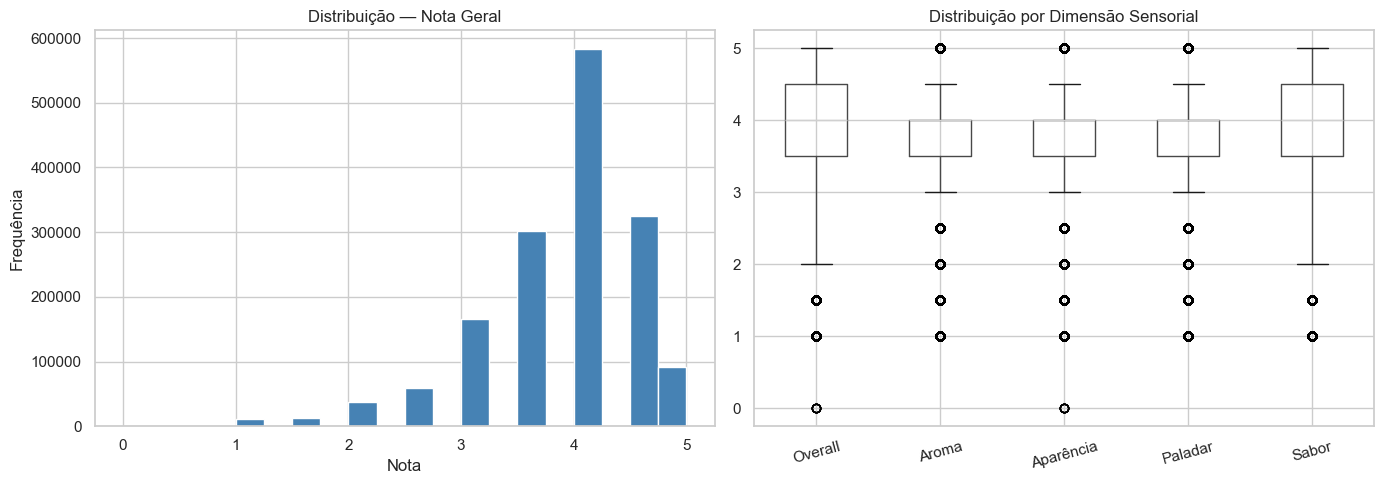

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['review_overall'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Nota Geral')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frequência')

# Boxplot por dimensão sensorial
sensoriais = ['review_overall', 'review_aroma', 'review_appearance',
              'review_palate', 'review_taste']
df[sensoriais].boxplot(ax=axes[1])
axes[1].set_title('Distribuição por Dimensão Sensorial')
axes[1].set_xticklabels(['Overall', 'Aroma', 'Aparência', 'Paladar', 'Sabor'], rotation=15)

plt.tight_layout()
plt.show()

In [9]:
nota_por_estilo = (
    df.groupby('beer_style')
    .agg(
        media_overall=('review_overall', 'mean'),
        total_reviews=('review_overall', 'count')
    )
    .query('total_reviews >= 500')  # filtra estilos com volume relevante
    .sort_values('media_overall', ascending=False)
    .head(20)
    .reset_index()
)

fig = px.bar(
    nota_por_estilo,
    x='media_overall', y='beer_style',
    orientation='h',
    title='Top 20 Estilos por Nota Média (mín. 500 reviews)',
    labels={'media_overall': 'Nota Média', 'beer_style': 'Estilo'},
    color='media_overall',
    color_continuous_scale='Blues',
    text=nota_por_estilo['media_overall'].round(2)
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [10]:
# Amostra pra não travar o plot
sample = df.dropna(subset=['beer_abv']).sample(10000, random_state=42)

fig = px.scatter(
    sample,
    x='beer_abv', y='review_overall',
    opacity=0.3,
    trendline='ols',
    title='ABV vs Nota Geral (amostra 10k)',
    labels={'beer_abv': 'ABV (%)', 'review_overall': 'Nota Geral'},
    color_discrete_sequence=['steelblue']
)
fig.update_layout(xaxis_range=[0, 20])
fig.show()

# Correlação numérica
corr = df[['beer_abv', 'review_overall']].corr().iloc[0, 1]
print(f"Correlação ABV x Nota Geral: {corr:.3f}")

Correlação ABV x Nota Geral: 0.143


In [11]:
top_cervejarias = (
    df.groupby('brewery_name')
    .agg(
        media_overall=('review_overall', 'mean'),
        total_reviews=('review_overall', 'count')
    )
    .query('total_reviews >= 1000')
    .sort_values('media_overall', ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    top_cervejarias,
    x='media_overall', y='brewery_name',
    orientation='h',
    title='Top 15 Cervejarias por Nota Média (mín. 1000 reviews)',
    labels={'media_overall': 'Nota Média', 'brewery_name': 'Cervejaria'},
    color='total_reviews',
    color_continuous_scale='Greens',
    text=top_cervejarias['media_overall'].round(2)
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

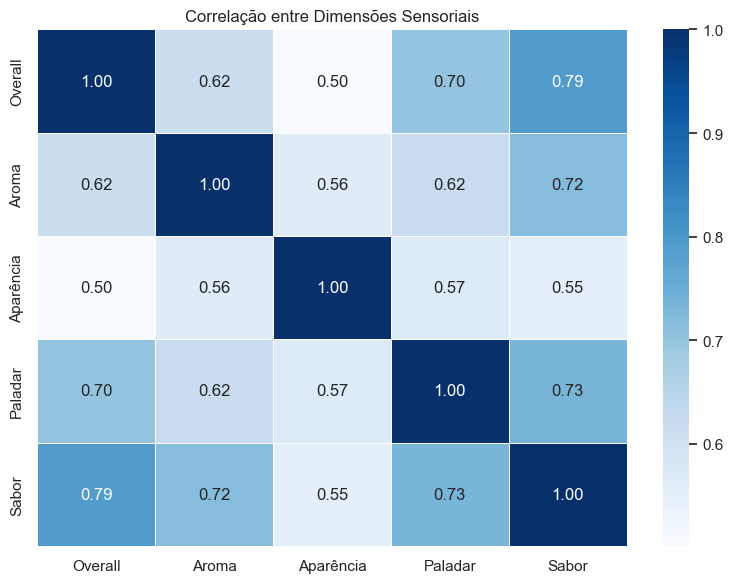

In [12]:
sensoriais = ['review_overall', 'review_aroma', 'review_appearance',
              'review_palate', 'review_taste']

corr_matrix = df[sensoriais].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=['Overall', 'Aroma', 'Aparência', 'Paladar', 'Sabor'],
    yticklabels=['Overall', 'Aroma', 'Aparência', 'Paladar', 'Sabor']
)
plt.title('Correlação entre Dimensões Sensoriais')
plt.tight_layout()
plt.show()

In [13]:
top5_estilos = df['beer_style'].value_counts().head(5).index

evolucao = (
    df[df['beer_style'].isin(top5_estilos)]
    .groupby(['review_year', 'beer_style'])
    .size()
    .reset_index(name='total_reviews')
)

fig = px.line(
    evolucao,
    x='review_year', y='total_reviews',
    color='beer_style',
    title='Evolução dos Top 5 Estilos ao Longo do Tempo',
    labels={'review_year': 'Ano', 'total_reviews': 'Total de Reviews', 'beer_style': 'Estilo'},
    markers=True
)
fig.show()